In [8]:
import numpy as np
import joblib
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [9]:
# Load test data
X_test_full = np.load('artifacts/X_test_scaled.npy')
y_test = np.load('artifacts/y_test_encoded.npy')

indices = joblib.load('artifacts/selected_indices.joblib')

stage0_if = joblib.load('models/stage0_if.joblib')
stage1_lr = joblib.load('models/stage1_lr.joblib')
stage1b_svm = joblib.load('models/stage1b_svm.joblib')
stage2_lgbm = joblib.load('models/stage2_lgbm.joblib')
stage2_xgb = joblib.load('models/stage2_xgb.joblib')

print("Data and all 4 models loaded successfully.")

Data and all 4 models loaded successfully.


In [10]:
X_test_reduced = X_test_full[:, indices]
y_test_binary_actual = np.isin(y_test, [0, 1, 2]).astype(int)

In [11]:
clean_samples = X_test_reduced[:100]
anomalies = np.random.uniform(low=10, high=50, size=(20, len(indices)))
mixed_stream = np.vstack((clean_samples, anomalies))

stage0_preds = stage0_if.predict(mixed_stream)

anomalies_caught = np.sum(stage0_preds == -1)
false_positives = np.sum(stage0_preds[:100] == -1) 

print("STAGE 0 DEFENSE METRICS")
print(f"Injected extreme anomalies: 20")
print(f"Anomalies successfully blocked: {anomalies_caught}")
print(f"False Positives (Clean data blocked): {false_positives}/100")

STAGE 0 DEFENSE METRICS
Injected extreme anomalies: 20
Anomalies successfully blocked: 20
False Positives (Clean data blocked): 0/100


STAGE 1 (LOGISTIC REGRESSION) ROUTING
Total Test Samples: 2947
Routed to Stage 1B (Static SVM): 1559 (52.9%)
Routed to Stage 2 (LightGBM): 1388 (47.1%)
Gatekeeper Accuracy: 99.97%



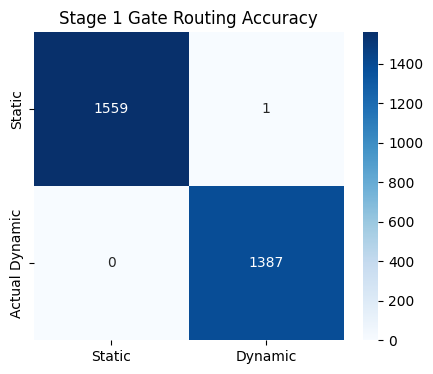

In [12]:
lr_preds = stage1_lr.predict(X_test_reduced)

total_samples = len(y_test)
routed_to_static = np.sum(lr_preds == 0)
routed_to_dynamic = np.sum(lr_preds == 1)
gatekeeper_acc = accuracy_score(y_test_binary_actual, lr_preds)

print("STAGE 1 (LOGISTIC REGRESSION) ROUTING")
print(f"Total Test Samples: {total_samples}")
print(f"Routed to Stage 1B (Static SVM): {routed_to_static} ({(routed_to_static/total_samples)*100:.1f}%)")
print(f"Routed to Stage 2 (LightGBM): {routed_to_dynamic} ({(routed_to_dynamic/total_samples)*100:.1f}%)")
print(f"Gatekeeper Accuracy: {gatekeeper_acc*100:.2f}%\n")

cm = confusion_matrix(y_test_binary_actual, lr_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Static', 'Dynamic'], yticklabels=['Static', 'Actual Dynamic'])
plt.title('Stage 1 Gate Routing Accuracy')
plt.show()

In [13]:
# EVALUATE STAGE 1B: STATIC SPECIALIST
actual_static_mask = (y_test_binary_actual == 0)
X_test_static = X_test_reduced[actual_static_mask]
y_test_static = y_test[actual_static_mask]

svm_static_preds = stage1b_svm.predict(X_test_static)
print("STAGE 1B (LINEAR SVM) ACCURACY ")
print(f"Accuracy on Static Activity: {accuracy_score(y_test_static, svm_static_preds)*100:.2f}%")
print(classification_report(y_test_static, svm_static_preds, target_names=["SITTING", "STANDING", "LAYING"]))


# EVALUATE STAGE 2: DYNAMIC SPECIALIST 
actual_dynamic_mask = (y_test_binary_actual == 1)
X_test_dynamic = X_test_reduced[actual_dynamic_mask]
y_test_dynamic = y_test[actual_dynamic_mask]

lgbm_preds = stage2_lgbm.predict(X_test_dynamic)
print("STAGE 2 (LIGHTGBM) ACCURACY")
print(f"Accuracy on Dynamic Activity: {accuracy_score(y_test_dynamic, lgbm_preds)*100:.2f}%")
print(classification_report(y_test_dynamic, lgbm_preds, target_names=["WALKING", "UPSTAIRS", "DOWNSTAIRS"]))

STAGE 1B (LINEAR SVM) ACCURACY 
Accuracy on Static Activity: 93.65%
              precision    recall  f1-score   support

     SITTING       0.94      0.86      0.89       491
    STANDING       0.88      0.95      0.91       532
      LAYING       1.00      1.00      1.00       537

    accuracy                           0.94      1560
   macro avg       0.94      0.93      0.94      1560
weighted avg       0.94      0.94      0.94      1560

STAGE 2 (LIGHTGBM) ACCURACY
Accuracy on Dynamic Activity: 92.50%
              precision    recall  f1-score   support

     WALKING       0.89      0.97      0.93       496
    UPSTAIRS       0.93      0.87      0.90       471
  DOWNSTAIRS       0.97      0.93      0.95       420

    accuracy                           0.93      1387
   macro avg       0.93      0.92      0.93      1387
weighted avg       0.93      0.93      0.92      1387



In [17]:
# 1. Benchmark Stage 1 (Logistic Regression)
start_time = time.perf_counter()
_ = stage1_lr.predict(X_test_reduced)
lr_ms_per_sample = ((time.perf_counter() - start_time) / len(X_test_reduced)) * 1000

# 2. Benchmark Stage 1B (Linear SVM)
start_time = time.perf_counter()
_ = stage1b_svm.predict(X_test_static)
svm_ms_per_sample = ((time.perf_counter() - start_time) / len(X_test_static)) * 1000

# 3. Benchmark Stage 2 (LightGBM)
start_time = time.perf_counter()
_ = stage2_lgbm.predict(X_test_dynamic)
lgbm_ms_per_sample = ((time.perf_counter() - start_time) / len(X_test_dynamic)) * 1000

print("INFERENCE LATENCY BENCHMARKS")
print(f"Stage 1 (Logistic Regression): {lr_ms_per_sample * 1000:.2f} μs per sample")
print(f"Stage 1B (Linear SVM): {svm_ms_per_sample * 1000:.2f} μs per sample")
print(f"Stage 2 (LightGBM): {lgbm_ms_per_sample * 1000:.2f} μs per sample")

computational_tax = lgbm_ms_per_sample / (lr_ms_per_sample + svm_ms_per_sample)
print(f"COMPUTATIONAL TAX: The LightGBM execution is approximately {computational_tax:.1f}x heavier than running both linear gatekeepers combined.")
print(f"By successfully gating {(routed_to_static/total_samples)*100:.1f}% of the physical data at Stage 1, the pipeline completely bypasses this processing tax, preserving mobile battery life.")

INFERENCE LATENCY BENCHMARKS
Stage 1 (Logistic Regression): 1.27 μs per sample
Stage 1B (Linear SVM): 1.30 μs per sample
Stage 2 (LightGBM): 9.11 μs per sample
COMPUTATIONAL TAX: The LightGBM execution is approximately 3.6x heavier than running both linear gatekeepers combined.
By successfully gating 52.9% of the physical data at Stage 1, the pipeline completely bypasses this processing tax, preserving mobile battery life.
